# Fraud Probability Analysis

This notebook audits the supplied fraud-probability labels, constructs consumer-date features, and compares six consumer-day regression models. Missing fraud records are never treated as zero. Same-day transaction aggregates describe the labelled day, while every historical feature uses information strictly before that date. The output is an end-of-day risk-score estimate, not a single-transaction real-time prediction.

In [1]:
import sys
import tempfile
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import Image, display

print(sys.executable)
print("DuckDB:", duckdb.__version__)
print("Pandas:", pd.__version__)

/home/changyuan/.venvs/project2/bin/python
DuckDB: 1.5.5
Pandas: 2.3.3


In [2]:
def find_member4_dir(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        direct = candidate if candidate.name == 'member4_fraud' else candidate / 'member4_fraud'
        if (direct / 'code').is_dir():
            return direct
    raise FileNotFoundError('Run this notebook from the repository or member4_fraud/code.')

MODULE_DIR = find_member4_dir()
CODE_DIR = MODULE_DIR / 'code'
REPO_ROOT = MODULE_DIR.parent
DATA_ROOT = REPO_ROOT.parent / 'data' / 'part1' / 'tables'
RESULTS_DIR = Path(tempfile.gettempdir()) / 'member4_fraud_work'
DELIVERY_DIR = MODULE_DIR / "result"
MODEL_OUTPUT_DIR = RESULTS_DIR / "consumer_model"
CONSUMER_FRAUD_PATH = DATA_ROOT / "consumer_fraud_probability.csv"
MERCHANT_FRAUD_PATH = DATA_ROOT / "merchant_fraud_probability.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DELIVERY_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory:", DATA_ROOT.exists())
print("Consumer fraud:", CONSUMER_FRAUD_PATH.exists())
print("Merchant fraud:", MERCHANT_FRAUD_PATH.exists())

Data directory: True
Consumer fraud: True
Merchant fraud: True


## 1. Load and audit the supplied labels

The supplied values are probability scores, not confirmed fraud cases. The tables contain entity-date labels and no `order_id`, so they must not be interpreted as one row per fraudulent transaction.

In [3]:
consumer_fraud = pd.read_csv(CONSUMER_FRAUD_PATH, parse_dates=["order_datetime"])
merchant_fraud = pd.read_csv(MERCHANT_FRAUD_PATH, parse_dates=["order_datetime"])
print("Consumer fraud shape:", consumer_fraud.shape)
print("Merchant fraud shape:", merchant_fraud.shape)
display(consumer_fraud.head(), merchant_fraud.head())

Consumer fraud shape: (34864, 3)
Merchant fraud shape: (114, 3)


,user_id,order_datetime,fraud_probability
0,6228,2021-12-19,97.629808
1,21419,2021-12-10,99.247380
2,5606,2021-10-17,84.058250
3,3101,2021-04-17,91.421921
4,22239,2021-10-19,94.703425


,merchant_abn,order_datetime,fraud_probability
0,19492220327,2021-11-28,44.403659
1,31334588839,2021-10-02,42.755301
2,19492220327,2021-12-22,38.867790
3,82999039227,2021-12-19,94.134700
4,90918180829,2021-09-02,43.325517


In [4]:
def audit_fraud_table(df, table_name, entity_col):
    key_cols = [entity_col, "order_datetime"]
    probability = df["fraud_probability"]
    return {
        "table": table_name,
        "rows": len(df),
        "unique_entities": df[entity_col].nunique(dropna=True),
        "duplicate_entity_date_rows": int(df.duplicated(key_cols).sum()),
        "missing_entity": int(df[entity_col].isna().sum()),
        "missing_date": int(df["order_datetime"].isna().sum()),
        "missing_probability": int(probability.isna().sum()),
        "min_date": df["order_datetime"].min(),
        "max_date": df["order_datetime"].max(),
        "min_probability": probability.min(),
        "mean_probability": probability.mean(),
        "median_probability": probability.median(),
        "max_probability": probability.max(),
        "probability_inside_0_100": bool(probability.dropna().between(0, 100).all()),
    }

fraud_source_audit = pd.DataFrame([
    audit_fraud_table(consumer_fraud, "consumer_fraud_probability", "user_id"),
    audit_fraud_table(merchant_fraud, "merchant_fraud_probability", "merchant_abn"),
])
display(fraud_source_audit.T)

,0,1
table,consumer_fraud_probability,merchant_fraud_probability
rows,34864,114
unique_entities,20128,61
duplicate_entity_date_rows,99,0
missing_entity,0,0
missing_date,0,0
missing_probability,0,0
min_date,2021-02-28 00:00:00,2021-03-25 00:00:00
max_date,2022-02-27 00:00:00,2022-02-27 00:00:00
min_probability,8.287144,18.210891


## 2. Review duplicate entity-date keys

Duplicated consumer keys are reviewed before aggregation. No label is silently discarded.

In [5]:
consumer_key = ["user_id", "order_datetime"]
merchant_key = ["merchant_abn", "order_datetime"]
consumer_duplicate_rows = consumer_fraud.loc[consumer_fraud.duplicated(consumer_key, keep=False)].sort_values(consumer_key + ["fraud_probability"])
consumer_duplicate_summary = (consumer_duplicate_rows.groupby(consumer_key, as_index=False)
    .agg(row_count=("fraud_probability", "size"), unique_probability_count=("fraud_probability", "nunique"),
         min_probability=("fraud_probability", "min"), mean_probability=("fraud_probability", "mean"),
         max_probability=("fraud_probability", "max")))
print("Consumer duplicated rows beyond first:", consumer_fraud.duplicated(consumer_key).sum())
print("Conflicting duplicate groups:", (consumer_duplicate_summary["unique_probability_count"] > 1).sum())
print("Merchant duplicated rows beyond first:", merchant_fraud.duplicated(merchant_key).sum())
display(consumer_duplicate_summary.head(20))

Consumer duplicated rows beyond first: 99
Conflicting duplicate groups: 0
Merchant duplicated rows beyond first: 0


,user_id,order_datetime,row_count,unique_probability_count,min_probability,mean_probability,max_probability
0,230,2021-08-28,2,1,86.283288,86.283288,86.283288
1,251,2021-12-31,2,1,82.970975,82.970975,82.970975
2,587,2021-12-14,2,1,65.740496,65.740496,65.740496
3,853,2021-11-30,2,1,80.593773,80.593773,80.593773
4,1169,2022-01-28,2,1,67.483935,67.483935,67.483935
5,1390,2022-02-16,2,1,74.419070,74.419070,74.419070
6,1428,2021-09-29,2,1,76.574879,76.574879,76.574879
7,1728,2021-12-22,2,1,77.958198,77.958198,77.958198
8,1900,2021-09-05,2,1,79.394235,79.394235,79.394235
9,1954,2021-12-31,2,1,66.171949,66.171949,66.171949


In [6]:
fraud_source_audit.to_csv(RESULTS_DIR / "fraud_source_audit.csv", index=False)
consumer_duplicate_summary.to_csv(RESULTS_DIR / "consumer_fraud_duplicate_key_summary.csv", index=False)
consumer_duplicate_rows.to_csv(RESULTS_DIR / "consumer_fraud_duplicate_rows.csv", index=False)
print("Saved label audit outputs to:", RESULTS_DIR)

Saved label audit outputs to: /tmp/member4_fraud_work


## 3. Curated transactions

Member 2's full curated transaction output contains one row per order and is partitioned by order year and month.

In [7]:
CURATED_TRANSACTION_ROOT = REPO_ROOT / "member2_curation" / "data" / "curated" / "curated_transactions"
transaction_parts = sorted(CURATED_TRANSACTION_ROOT.rglob("*.parquet"))
assert transaction_parts, f"No Parquet files found below {CURATED_TRANSACTION_ROOT}"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
print("Curated transaction directory:", CURATED_TRANSACTION_ROOT)
print("Monthly Parquet files:", len(transaction_parts))

transaction_glob = (CURATED_TRANSACTION_ROOT / 'order_year=*' / 'order_month=*' / '*.parquet').as_posix()
consumer_label_grain = duckdb.sql(f"""
    WITH labels AS (
        SELECT trim(cast(user_id AS VARCHAR)) AS user_id,
               cast(order_datetime AS DATE) AS observation_date
        FROM read_csv_auto('{CONSUMER_FRAUD_PATH.as_posix()}') GROUP BY 1, 2
    ), daily AS (
        SELECT trim(cast(user_id AS VARCHAR)) AS user_id,
               cast(order_datetime AS DATE) AS observation_date,
               count(*) AS order_count, count(DISTINCT merchant_abn) AS merchant_count
        FROM read_parquet('{transaction_glob}', hive_partitioning=true) GROUP BY 1, 2
    )
    SELECT count(*) AS labelled_consumer_days,
           count(*) FILTER (WHERE order_count > 1) AS multi_order_days,
           round(100.0 * count(*) FILTER (WHERE order_count > 1) / count(*), 2) AS multi_order_pct,
           count(*) FILTER (WHERE merchant_count > 1) AS multi_merchant_days,
           round(100.0 * count(*) FILTER (WHERE merchant_count > 1) / count(*), 2) AS multi_merchant_pct
    FROM labels JOIN daily USING (user_id, observation_date)
""").df()
display(consumer_label_grain)

Curated transaction directory: member2_curation/data/curated/curated_transactions
Monthly Parquet files: 21


,labelled_consumer_days,multi_order_days,multi_order_pct,multi_merchant_days,multi_merchant_pct
0,34765,25408,73.08,25406,73.08


## 4. Build leakage-aware feature tables

The modelling grain is one consumer-observation-date row because the fraud file has no `order_id`. Same-day orders are aggregated into order count, total spend, mean, maximum, dispersion, and merchant-count features; historical windows remain strictly earlier than the observation date. Duplicate labels with the same consumer, date, and probability are collapsed. DuckDB processes the 14.2 million transaction rows without loading them all into pandas.

In [8]:
from build_feature_tables import build_feature_tables

feature_table_summary = build_feature_tables(repo_root=REPO_ROOT, raw_tables_root=DATA_ROOT, output_dir=RESULTS_DIR)
display(feature_table_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,rows,entities,first_observation_date,last_observation_date,rows_with_30d_history,rows_with_90d_history,rows_without_prior_transactions,mean_consumer_risk_transaction_coverage_90d,min_target,mean_target,max_target
0,consumer,34765,20128,2021-02-28,2022-02-27,34239,33041,36,NaN,0.082871,0.149458,0.992474
1,merchant,114,61,2021-03-25,2022-02-27,113,112,2,0.692077,0.182109,0.404193,0.941347


In [9]:
CONSUMER_FEATURE_PATH = RESULTS_DIR / "consumer_fraud_features.parquet"
MERCHANT_FEATURE_PATH = RESULTS_DIR / "merchant_fraud_features.parquet"
feature_missingness = pd.read_csv(RESULTS_DIR / "feature_table_missingness.csv")
consumer_preview = duckdb.sql(f"""
    SELECT user_id, observation_date, fraud_probability,
           same_day_order_count, same_day_total_spend, same_day_max_order_value,
           same_day_unique_merchants, order_count_30d, spend_30d,
           unique_merchants_90d, history_coverage_90d
    FROM read_parquet('{CONSUMER_FEATURE_PATH.as_posix()}')
    ORDER BY observation_date, user_id LIMIT 5
""").df()
display(feature_missingness, consumer_preview)

,table_name,rows,missing_avg_order_value_90d,missing_order_value_cv_90d,missing_repeat_customer_rate_90d,missing_weighted_consumer_risk
0,consumer,34765,36,47,NaN,NaN
1,merchant,114,3,4,3.0,3.0


,user_id,observation_date,fraud_probability,same_day_order_count,same_day_total_spend,same_day_max_order_value,same_day_unique_merchants,order_count_30d,spend_30d,unique_merchants_90d,history_coverage_90d
0,11870,2021-02-28,0.306106,2,21010.726761,20991.988536,2,0,0.0,0,0.0
1,12185,2021-02-28,0.108151,3,4429.637371,4324.542067,3,0,0.0,0,0.0
2,13039,2021-02-28,0.106783,2,7225.017452,7033.242352,2,0,0.0,0,0.0
3,13663,2021-02-28,0.188201,2,9062.308127,8913.192190,2,0,0.0,0,0.0
4,13856,2021-02-28,0.109986,2,6792.076210,5369.954444,2,0,0.0,0,0.0


# Consumer fraud probability models

## 5. Preparation, validation design, and safeguards

- **Target:** supplied consumer-date `fraud_probability` normalized to 0–1. This is continuous risk-score regression, not a confirmed-fraud classifier.
- **Features:** same-day aggregates plus earlier behavioural history. IDs, target fields, later transactions, demographic identifiers, and deterministic duplicate velocity columns are excluded.
- **History:** modelling uses observations with a complete 90-day lookback.
- **Temporal split:** train before 1 Nov 2021; validation Nov–Dec 2021; test Jan 2022 onward. No random split.
- **Tuning:** validation MAE selects parameters; validation RMSE breaks ties. Test data is opened only after selection.
- **Interpretation:** same-day aggregates are valid only for an end-of-day consumer-date estimate. Because no `order_id` exists, the result cannot be attributed to one transaction or used as a claimed real-time prediction.
- **Preprocessing:** imputation and scaling are inside pipelines fitted on training data only.
- **Overfitting controls:** large K values, constrained trees, regularisation, subsampling, early stopping, and generalisation-gap reporting.
- **Ethics:** predictions support review only; they are not proof of fraud and must not independently trigger adverse action.

In [10]:
from train_consumer_models import MODEL_FEATURES, run_consumer_model_experiment

consumer_model_comparison = run_consumer_model_experiment(repo_root=REPO_ROOT, output_dir=RESULTS_DIR)
display(consumer_model_comparison)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,model,selected_by_validation,best_parameters,validation_mae,validation_rmse,validation_r2,validation_spearman,train_validation_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_validation_mae
0,XGBoost,True,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.012290,0.018696,0.960769,0.940693,1.125344e-02,0.009443,0.014655,0.977229,0.970642,-0.001811
1,Random Forest,False,"{""max_depth"": 10, ""max_features"": 0.7, ""min_sa...",0.013281,0.020477,0.952941,0.935425,1.193133e-02,0.011748,0.018557,0.963489,0.956810,-0.000183
2,KNN,False,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan...",0.031548,0.044314,0.779603,0.616993,3.955624e-09,0.025900,0.034905,0.870826,0.749473,0.025900
3,Linear Regression,False,"{""fit_intercept"": true}",0.042782,0.048267,0.738523,0.810736,2.179382e-02,0.037937,0.042943,0.804479,0.872527,0.016143
4,Median Baseline,False,{},0.051531,0.099390,-0.108690,0.000000,5.171796e-02,0.053416,0.103117,-0.127393,0.000000,0.001698
5,Mean Baseline,False,{},0.059188,0.094397,-0.000100,0.000000,5.893675e-02,0.059925,0.097150,-0.000688,0.000000,0.000988


In [11]:
split_summary = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_data_split_summary.csv")
split_overlap = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_split_user_overlap.csv")
feature_diagnostics = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_feature_diagnostics.csv")
high_correlations = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_high_correlation_pairs.csv")
vif = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_vif.csv")
display(split_summary, split_overlap, feature_diagnostics, high_correlations.head(20), vif.head(20))

,split,rows,unique_users,first_date,last_date,mean_target
0,train,12134,10008,2021-05-29,2021-10-31,0.149507
1,validation,13952,11223,2021-11-01,2021-12-31,0.148561
2,test,6955,6244,2022-01-01,2022-02-27,0.151549


,comparison,overlapping_users
0,train_vs_validation,3924
1,train_vs_test,2159
2,validation_vs_test,2404


,feature,missing_rate,unique_values,standard_deviation,near_zero_variance
0,same_day_order_count,0.0,8,1.029404,False
1,same_day_total_spend,0.0,12134,4657.946685,False
2,same_day_avg_order_value,0.0,12134,3104.048322,False
3,same_day_max_order_value,0.0,12134,4661.302533,False
4,same_day_order_value_std,0.0,8695,3064.305626,False
5,same_day_unique_merchants,0.0,8,1.027582,False
6,same_day_high_value_transaction_ratio,0.0,11,0.292918,False
7,same_day_order_value_cv,0.0,8695,0.675419,False
8,lifetime_order_count,0.0,191,34.747327,False
9,lifetime_spend,0.0,12134,8101.527185,False


,feature_1,feature_2,correlation,absolute_correlation
0,same_day_order_count,same_day_unique_merchants,0.998991,0.998991
1,same_day_total_spend,same_day_max_order_value,0.995948,0.995948
2,avg_order_value_90d,spend_per_merchant_90d,0.988742,0.988742
3,max_order_value_90d,order_value_std_90d,0.988523,0.988523
4,spend_90d,spend_per_merchant_90d,0.938731,0.938731
5,spend_90d,avg_order_value_90d,0.935774,0.935774
6,order_count_90d,unique_merchants_90d,0.915044,0.915044
7,max_order_value_90d,order_value_cv_90d,0.913625,0.913625


,feature,vif
0,avg_order_value_90d,518.572865
1,spend_per_merchant_90d,515.939279
2,same_day_order_count,501.804643
3,same_day_unique_merchants,496.858372
4,same_day_max_order_value,231.765486
5,same_day_total_spend,220.095368
6,order_value_std_90d,131.060410
7,spend_90d,121.104075
8,max_order_value_90d,106.857041
9,order_count_90d,69.178992


## 6. Models 1–2 — Median and mean baselines

The median baseline is the natural reference for MAE, while the mean baseline is the standard reference for RMSE and R². A complex model is useful only if it beats these simple references on forward validation.

In [12]:
tuning = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_model_tuning_results.csv")
forms = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_best_model_forms.csv")
baseline_names = ['Median Baseline', 'Mean Baseline']
display(tuning.query("model in @baseline_names"), forms.query("model in @baseline_names"))

,model,config_id,parameters,best_iteration,fit_seconds,train_mae,train_rmse,train_r2,train_spearman,validation_mae,validation_rmse,validation_r2,validation_spearman,validation_minus_train_mae,selected_within_model
7,Mean Baseline,mean_baseline_01,{},NaN,0.046822,0.059090,0.092947,0.000000,0.0,0.059188,0.094397,-0.00010,0.0,0.000097,True
8,Median Baseline,median_baseline_01,{},NaN,0.085849,0.051939,0.098323,-0.119014,0.0,0.051531,0.099390,-0.10869,0.0,-0.000409,True


,model,preprocessing,best_form,best_parameters,saved_model
0,Median Baseline,Median imputation,Constant prediction equal to the train+validat...,{},models/median_baseline.joblib
1,Mean Baseline,Median imputation,Constant prediction equal to the train+validat...,{},models/mean_baseline.joblib


## 7. Model 3 — K-nearest neighbours

KNN is tuned over neighbour count and weighting. Scaling is training-only. Its train-to-test MAE gap is reported because distance weighting can memorise training observations.

In [13]:
display(tuning.query("model == 'KNN'").sort_values(['validation_mae', 'validation_rmse']), forms.query("model == 'KNN'"))

,model,config_id,parameters,best_iteration,fit_seconds,train_mae,train_rmse,train_r2,train_spearman,validation_mae,validation_rmse,validation_r2,validation_spearman,validation_minus_train_mae,selected_within_model
0,KNN,knn_02,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan...",NaN,0.493860,2.999338e-09,1.027968e-08,1.000000,1.000000,0.031548,0.044314,0.779603,0.616993,0.031548,True
1,KNN,knn_01,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""uniform""}",NaN,0.666988,2.579772e-02,3.652940e-02,0.845541,0.760544,0.031685,0.044576,0.776986,0.614636,0.005888,False
2,KNN,knn_04,"{""n_neighbors"": 35, ""p"": 2, ""weights"": ""distan...",NaN,0.357543,7.033292e-09,2.379224e-08,1.000000,1.000000,0.032811,0.046704,0.755186,0.683328,0.032811,False
3,KNN,knn_03,"{""n_neighbors"": 35, ""p"": 2, ""weights"": ""uniform""}",NaN,0.445082,2.815309e-02,3.996230e-02,0.815146,0.760924,0.033000,0.047072,0.751312,0.681007,0.004847,False
4,KNN,knn_06,"{""n_neighbors"": 75, ""p"": 2, ""weights"": ""distan...",NaN,0.417416,1.503243e-08,5.119838e-08,1.000000,1.000000,0.034662,0.050225,0.716879,0.725930,0.034662,False
5,KNN,knn_05,"{""n_neighbors"": 75, ""p"": 2, ""weights"": ""uniform""}",NaN,0.431854,3.027405e-02,4.360361e-02,0.779924,0.774401,0.034916,0.050749,0.710940,0.722845,0.004642,False


,model,preprocessing,best_form,best_parameters,saved_model
2,KNN,Median imputation followed by StandardScaler f...,Average or distance-weighted average of the k ...,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan...",models/knn.joblib


## 8. Model 4 — Linear regression

This is an interpretable reference. Correlation and VIF tables document multicollinearity; coefficients are descriptive, not causal.

In [14]:
linear_coefficients = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_linear_regression_coefficients.csv")
linear_top = linear_coefficients.sort_values('absolute_coefficient', ascending=False).head(15)
display(tuning.query("model == 'Linear Regression'"), forms.query("model == 'Linear Regression'"), linear_top)

,model,config_id,parameters,best_iteration,fit_seconds,train_mae,train_rmse,train_r2,train_spearman,validation_mae,validation_rmse,validation_r2,validation_spearman,validation_minus_train_mae,selected_within_model
6,Linear Regression,linear_regression_01,"{""fit_intercept"": true}",NaN,0.060076,0.023916,0.035146,0.857018,0.816236,0.042782,0.048267,0.738523,0.810736,0.018867,True


,model,preprocessing,best_form,best_parameters,saved_model
3,Linear Regression,Median imputation followed by StandardScaler f...,prediction = intercept + sum(standardized feat...,"{""fit_intercept"": true}",models/linear_regression.joblib


,feature,standardized_coefficient,absolute_coefficient,intercept
0,same_day_total_spend,0.131415,0.131415,0.149001
1,lifetime_order_count,0.031181,0.031181,0.149001
2,same_day_max_order_value,-0.024288,0.024288,0.149001
3,same_day_order_value_std,-0.020833,0.020833,0.149001
4,spend_per_merchant_90d,0.017421,0.017421,0.149001
5,order_count_90d,-0.015321,0.015321,0.149001
6,same_day_order_value_cv,0.014774,0.014774,0.149001
7,lifetime_spend,-0.012522,0.012522,0.149001
8,spend_90d,-0.012248,0.012248,0.149001
9,avg_order_value_90d,-0.010089,0.010089,0.149001


## 9. Model 5 — Random forest

Candidates use constrained depth and minimum leaf sizes to reduce the risk of learning rare individual patterns.

In [15]:
tree_importance = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_tree_feature_importance.csv")
display(tuning.query("model == 'Random Forest'").sort_values(['validation_mae', 'validation_rmse']),
        forms.query("model == 'Random Forest'"), tree_importance.query("model == 'Random Forest'").head(15))

,model,config_id,parameters,best_iteration,fit_seconds,train_mae,train_rmse,train_r2,train_spearman,validation_mae,validation_rmse,validation_r2,validation_spearman,validation_minus_train_mae,selected_within_model
9,Random Forest,random_forest_02,"{""max_depth"": 10, ""max_features"": 0.7, ""min_sa...",NaN,3.469035,0.013709,0.022126,0.943334,0.916572,0.013281,0.020477,0.952941,0.935425,-0.000428,True
10,Random Forest,random_forest_06,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",NaN,6.812927,0.015033,0.025348,0.925626,0.907515,0.013720,0.021957,0.945890,0.931580,-0.001312,False
11,Random Forest,random_forest_04,"{""max_depth"": 8, ""max_features"": 1.0, ""min_sam...",NaN,5.148331,0.015173,0.025624,0.924000,0.905021,0.014008,0.022155,0.944911,0.932010,-0.001164,False
12,Random Forest,random_forest_01,"{""max_depth"": 6, ""max_features"": 0.7, ""min_sam...",NaN,2.548907,0.015641,0.024248,0.931944,0.889772,0.014239,0.021716,0.947071,0.918036,-0.001402,False
13,Random Forest,random_forest_03,"{""max_depth"": 12, ""max_features"": ""sqrt"", ""min...",NaN,1.657579,0.014572,0.022894,0.939332,0.911889,0.014538,0.023124,0.939984,0.923739,-0.000034,False
14,Random Forest,random_forest_05,"{""max_depth"": 12, ""max_features"": ""sqrt"", ""min...",NaN,2.374699,0.016157,0.026093,0.921188,0.901104,0.015266,0.025165,0.928926,0.920672,-0.000891,False


,model,preprocessing,best_form,best_parameters,saved_model
4,Random Forest,Median imputation fitted on training data only...,Average prediction from constrained regression...,"{""max_depth"": 10, ""max_features"": 0.7, ""min_sa...",models/random_forest.joblib


,model,feature,importance
0,Random Forest,same_day_total_spend,0.593365
1,Random Forest,same_day_max_order_value,0.258621
2,Random Forest,lifetime_order_count,0.069129
3,Random Forest,same_day_avg_order_value,0.039721
4,Random Forest,lifetime_spend,0.013009
5,Random Forest,same_day_order_value_std,0.011529
6,Random Forest,avg_order_value_90d,0.004949
7,Random Forest,spend_per_merchant_90d,0.003855
8,Random Forest,spend_90d,0.001286
9,Random Forest,order_value_std_90d,0.001011


## 10. Model 6 — XGBoost

Candidates use shallow trees, row/column subsampling, regularisation, and validation-only early stopping. Retained boosting rounds are saved with the best form.

In [16]:
display(tuning.query("model == 'XGBoost'").sort_values(['validation_mae', 'validation_rmse']),
        forms.query("model == 'XGBoost'"), tree_importance.query("model == 'XGBoost'").head(15))

,model,config_id,parameters,best_iteration,fit_seconds,train_mae,train_rmse,train_r2,train_spearman,validation_mae,validation_rmse,validation_r2,validation_spearman,validation_minus_train_mae,selected_within_model
15,XGBoost,xgboost_04,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",489.0,1.044235,0.013278,0.020157,0.952968,0.911637,0.012290,0.018696,0.960769,0.940693,-0.000988,True
16,XGBoost,xgboost_06,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",291.0,0.649517,0.013352,0.020300,0.952302,0.910927,0.012318,0.018694,0.960779,0.941061,-0.001034,False
17,XGBoost,xgboost_03,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",315.0,0.609421,0.013846,0.020995,0.948978,0.905931,0.012403,0.018872,0.960028,0.940006,-0.001443,False
18,XGBoost,xgboost_01,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",868.0,1.520788,0.014616,0.022557,0.941105,0.900387,0.012471,0.018961,0.959649,0.939217,-0.002145,False
19,XGBoost,xgboost_02,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",489.0,0.904534,0.014103,0.021601,0.945992,0.904702,0.012491,0.019036,0.959329,0.939743,-0.001612,False
20,XGBoost,xgboost_05,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",281.0,0.425502,0.014710,0.022586,0.940949,0.899815,0.012683,0.019265,0.958345,0.937523,-0.002027,False


,model,preprocessing,best_form,best_parameters,saved_model
5,XGBoost,Native missing-value handling; no scaling.,Regularized additive boosted regression trees ...,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


,model,feature,importance
28,XGBoost,same_day_total_spend,0.480678
29,XGBoost,same_day_max_order_value,0.292358
30,XGBoost,lifetime_order_count,0.063795
31,XGBoost,same_day_avg_order_value,0.037021
32,XGBoost,avg_order_value_90d,0.017936
33,XGBoost,same_day_order_count,0.015304
34,XGBoost,same_day_order_value_std,0.013559
35,XGBoost,lifetime_spend,0.011036
36,XGBoost,spend_per_merchant_90d,0.010160
37,XGBoost,order_value_std_90d,0.008136


## 11. Final comparison and saved outputs

The selected model has the lowest validation MAE—not the lowest test MAE. Each fixed model is refitted on train + validation, then evaluated once on the held-out test period.

,model,selected_by_validation,best_parameters,validation_mae,validation_rmse,validation_r2,validation_spearman,train_validation_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_validation_mae
0,XGBoost,True,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.012290,0.018696,0.960769,0.940693,1.125344e-02,0.009443,0.014655,0.977229,0.970642,-0.001811
1,Random Forest,False,"{""max_depth"": 10, ""max_features"": 0.7, ""min_sa...",0.013281,0.020477,0.952941,0.935425,1.193133e-02,0.011748,0.018557,0.963489,0.956810,-0.000183
2,KNN,False,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan...",0.031548,0.044314,0.779603,0.616993,3.955624e-09,0.025900,0.034905,0.870826,0.749473,0.025900
3,Linear Regression,False,"{""fit_intercept"": true}",0.042782,0.048267,0.738523,0.810736,2.179382e-02,0.037937,0.042943,0.804479,0.872527,0.016143
4,Median Baseline,False,{},0.051531,0.099390,-0.108690,0.000000,5.171796e-02,0.053416,0.103117,-0.127393,0.000000,0.001698
5,Mean Baseline,False,{},0.059188,0.094397,-0.000100,0.000000,5.893675e-02,0.059925,0.097150,-0.000688,0.000000,0.000988


,model,preprocessing,best_form,best_parameters,saved_model
0,Median Baseline,Median imputation,Constant prediction equal to the train+validat...,{},models/median_baseline.joblib
1,Mean Baseline,Median imputation,Constant prediction equal to the train+validat...,{},models/mean_baseline.joblib
2,KNN,Median imputation followed by StandardScaler f...,Average or distance-weighted average of the k ...,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan...",models/knn.joblib
3,Linear Regression,Median imputation followed by StandardScaler f...,prediction = intercept + sum(standardized feat...,"{""fit_intercept"": true}",models/linear_regression.joblib
4,Random Forest,Median imputation fitted on training data only...,Average prediction from constrained regression...,"{""max_depth"": 10, ""max_features"": 0.7, ""min_sa...",models/random_forest.joblib
5,XGBoost,Native missing-value handling; no scaling.,Regularized additive boosted regression trees ...,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


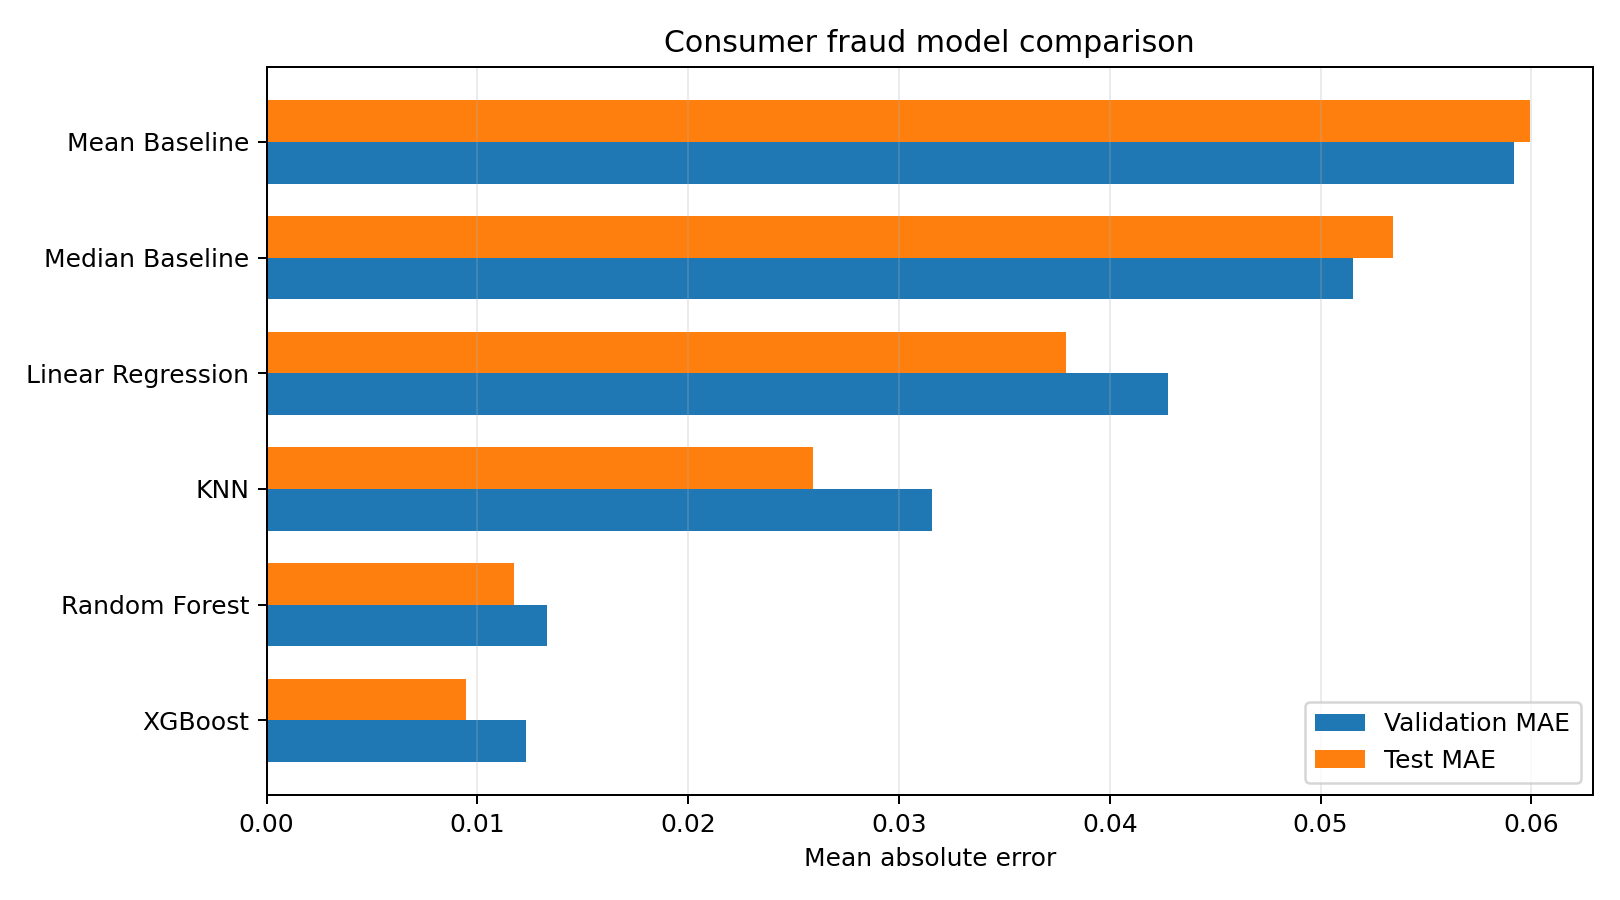

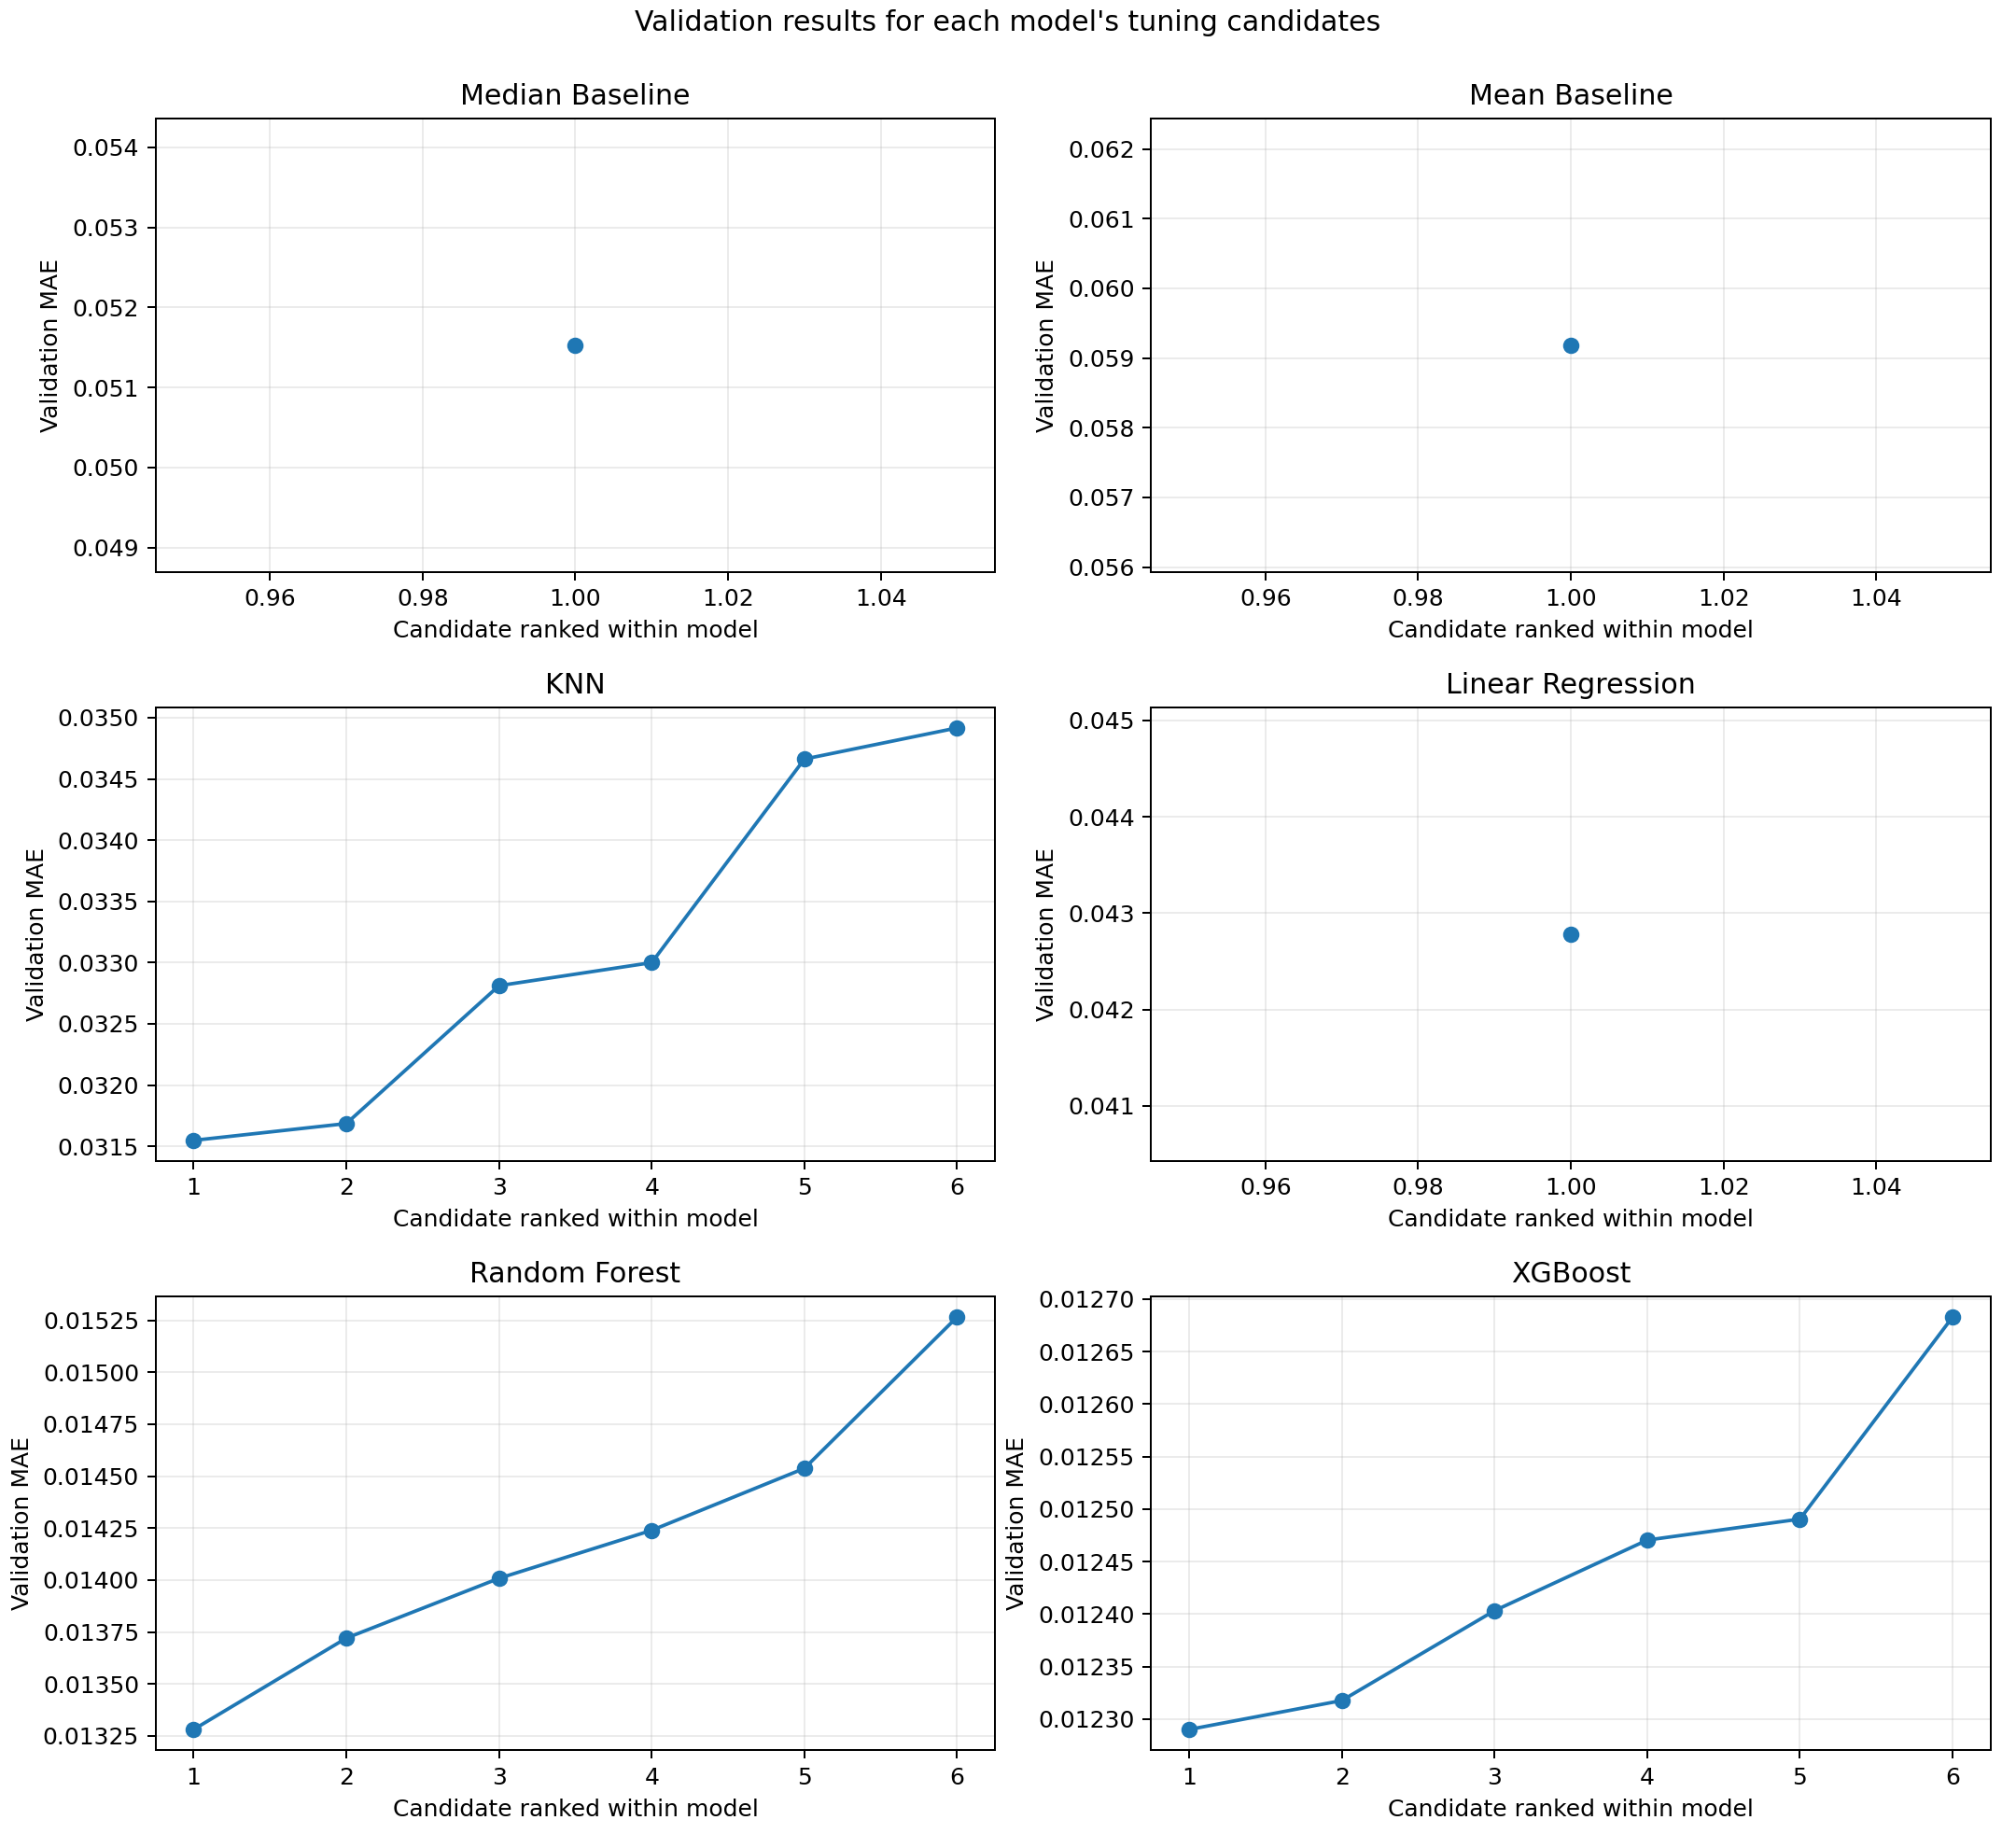

In [17]:
comparison = pd.read_csv(MODEL_OUTPUT_DIR / "consumer_model_comparison.csv")
display(comparison, forms)
display(Image(filename=str(MODEL_OUTPUT_DIR / 'figures' / 'consumer_model_comparison.png')))
display(Image(filename=str(MODEL_OUTPUT_DIR / 'figures' / 'consumer_model_tuning_validation.png')))

In [18]:
all_predictions_path = MODEL_OUTPUT_DIR / "consumer_fraud_predictions_all.parquet"
prediction_audit = duckdb.sql(f"""
    SELECT count(*) AS rows, count(DISTINCT user_id) AS unique_consumers,
           min(predicted_consumer_fraud_probability) AS min_prediction,
           avg(predicted_consumer_fraud_probability) AS mean_prediction,
           max(predicted_consumer_fraud_probability) AS max_prediction,
           count(DISTINCT predicted_consumer_fraud_probability) AS distinct_predictions
    FROM read_parquet('{all_predictions_path.as_posix()}')
""").df()
display(prediction_audit)
delivery_files = [
    'consumer_best_model_forms.csv',
    'consumer_data_split_summary.csv',
    'consumer_model_comparison.csv',
    'consumer_model_tuning_results.csv',
    'consumer_selected_model_feature_importance.csv',
    'consumer_split_user_overlap.csv',
    'consumer_fraud_predictions_all.csv',
]
for filename in delivery_files:
    source = MODEL_OUTPUT_DIR / filename
    target = DELIVERY_DIR / filename
    target.write_bytes(source.read_bytes())
print("Delivered consumer CSV files to:", DELIVERY_DIR)

,rows,unique_consumers,min_prediction,mean_prediction,max_prediction,distinct_predictions
0,24081,24081,0.061769,0.142966,0.61699,24021


Delivered consumer CSV files to: member4_fraud/result


## 12. Interpretation and responsible use

A model is accepted only when it beats the mean baseline on forward validation and remains stable on the later test period. Feature importance is descriptive, not causal. The supplied score's provenance and fairness properties remain unknown; demographic variables are intentionally excluded. Because 73.08% of labelled consumer-days involve multiple merchants, this daily score must not be attributed to a particular order or merchant without an additional mapping key. Operational use would require provenance documentation, subgroup error auditing, human review, appeal mechanisms, and drift monitoring.